# **Notebook 2** - Inspecting & Processing Seismic Data

### MVP1 goals: Data inspection, preprocessing, visualizations

In Notebook 1, we learned how to discover seismic events, select stations, retrieve waveform data, and store the results as a reusable data product.

In this notebook, we take the next step: we inspect the retrieved waveforms and decide whether they are ready for analysis.

A waveform dataset is not automatically useful just because it was retrieved successfully. Some traces may have gaps, missing channels, unusual sampling rates, incomplete metadata, noisy records, or unavailable instrument response information. Before using the data for scientific interpretation, we need to check its quality and prepare it consistently.

In [1]:
# first we read the inventory and metadata that we saved in Notebook1_mvp1.ipynb
from obspy import read_inventory
st_inv = read_inventory("station_inventory.xml")

import pandas as pd
df = pd.read_csv("station_dataframe.csv")

import json
from obspy import UTCDateTime

with open("event_selection.json", "r") as f:
    event_selection = json.load(f)

event_time = UTCDateTime(event_selection["event_time"])
t1 = UTCDateTime(event_selection["start_time"])
t2 = UTCDateTime(event_selection["end_time"])
target_channel = event_selection["target_channel"]

df


,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available
0,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True
1,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True
2,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True
3,UW,ERW,1997-12-01T00:00:00.000000Z,48.453827,-122.626121,387.0,HNZ,200.0,True
4,UW,HURR,2017-05-10T00:00:00.000000Z,47.970350,-123.498710,1605.0,HNZ,200.0,True
5,UW,LWCK,2015-01-29T00:00:00.000000Z,46.277800,-124.053600,60.4,HNZ,200.0,True
6,UW,MAC,2018-06-25T00:00:00.000000Z,47.246700,-122.531800,112.5,HNZ,200.0,True
7,UW,OOW2,2015-03-03T00:00:00.000000Z,47.749190,-124.175440,741.0,HNZ,200.0,True
8,UW,QCDG,2011-11-16T00:00:00.000000Z,48.100020,-122.586960,52.2,HNZ,200.0,True
9,UW,QCEN,2012-06-14T00:00:00.000000Z,46.716350,-122.961900,55.4,HNZ,200.0,True


In [37]:
from obspy.clients.fdsn import Client
client = Client("https://service.earthscope.org")

## **1. Data Inspection**

#### **1.1 Waveform inspection--Gaps/Overlaps**


When waveform data are requested using ObsPy, the returned object is a `Stream`. A `Stream` is a container that can hold one or more `Trace` objects. In many simple cases, a request for one station, one channel, and one time window returns a single continuous `Trace`. However, it is also common for the returned `Stream` to contain multiple `Trace` objects.

Multiple traces inside one `Stream` do not automatically mean that something is wrong with the data. They simply indicate that the waveform was returned as separate segments. These segments may represent truly discontinuous data, but they may also be perfectly continuous in time and only separated internally by the data service.

There are several possible reasons why a single waveform request may return multiple traces:

- the waveform contains a real data gap,
- two waveform segments overlap in time,
- the waveform is split into adjacent but continuous time segments,
- there is a small timing break between packets,
- or the data service stores and returns the waveform in multiple pieces.

Therefore, simply checking the number of traces using `len(st)` is only a first diagnostic step. A `Stream` with more than one trace may still have no actual gaps or overlaps. To determine whether the trace segments are truly discontinuous, we should use ObsPy’s built-in `get_gaps()` method.

The `get_gaps()` method checks the timing relationship between adjacent traces in the `Stream`. It reports both gaps and overlaps. A positive time difference indicates a gap, while a negative time difference indicates an overlap. If `get_gaps()` returns an empty list, then ObsPy did not detect any gaps or overlaps, even if the `Stream` contains multiple traces.

In the code below, we loop through each station in the dataframe, request waveform data for the selected time window, and then inspect the returned `Stream`. For each station, we print the number of traces retrieved and check whether ObsPy detects any gaps or overlaps. This allows us to distinguish between waveforms that are merely split into multiple continuous segments and waveforms that contain actual timing problems.

This step is useful before merging, plotting, or applying further processing. If no gaps or overlaps are detected, the traces can usually be merged safely. If gaps or overlaps are detected, the waveform should be inspected more carefully before deciding how to handle missing or duplicated data.

In [41]:
# Retrieve waveform data for each station in the DataFrame and store information data gaps
gaps_info = []  # Initialize an empty list to store gap information
for i in range(len(df)):

    # 1. go through each row in the DataFrame
    row_number = i          

    # 2. Retrieve the station and network codes from the DataFrame
    station = df.iloc[row_number].station
    network = df.iloc[row_number].network
    
    # 3. Retrieve the waveform data for the specified station and channel
    st = client.get_waveforms(
        network=network,
        station=station,
        location="*",
        channel="HNZ",
        starttime=t1,
        endtime=t2
    )

    # 4. Sort the traces in the stream by start time
    st.sort()                   

    print(f"\nStation {station} ({network})")
    print(f"Retrieved {len(st)} trace(s)")

    # 5. Print the details of each trace in the stream
    for j, tr in enumerate(st):
        print(
            f"  Trace {j+1}: {tr.id}, "                     # 5.1 Print the trace ID
            f"{tr.stats.starttime} to {tr.stats.endtime}, " # 5.2 Print the start and end times of the trace
            f"npts={tr.stats.npts}, "                       # 5.3 Print the number of points in the trace
            f"dt={tr.stats.delta}"                          # 5.4 Print the sample interval of the trace
        )

    # 6. Check for gaps in the stream
    gaps = st.get_gaps()
    if not gaps:
        print("No gaps or overlaps detected.")
        gaps_info.append(False) # Append False to the gaps list if no gaps are detected
    else:
        print("Gaps/overlaps detected:")
        gaps_info.append(True) # Append True to the gaps list if gaps are detected
        for gap in gaps:
            print(gap)


Station NLWA (US)
Retrieved 2 trace(s)
  Trace 1: US.NLWA.20.HNZ, 2018-11-19T11:07:59.735000Z to 2018-11-19T11:09:06.510000Z, npts=13356, dt=0.005
  Trace 2: US.NLWA.20.HNZ, 2018-11-19T11:09:06.515000Z to 2018-11-19T11:11:28.110000Z, npts=28320, dt=0.005
No gaps or overlaps detected.

Station BILS (UW)
Retrieved 1 trace(s)
  Trace 1: UW.BILS..HNZ, 2018-11-19T11:07:13.130000Z to 2018-11-19T11:17:13.130000Z, npts=120001, dt=0.005
No gaps or overlaps detected.

Station BLN (UW)
Retrieved 1 trace(s)
  Trace 1: UW.BLN..HNZ, 2018-11-19T11:07:13.130000Z to 2018-11-19T11:17:13.130000Z, npts=120001, dt=0.005
No gaps or overlaps detected.

Station ERW (UW)
Retrieved 1 trace(s)
  Trace 1: UW.ERW..HNZ, 2018-11-19T11:07:13.130000Z to 2018-11-19T11:17:13.130000Z, npts=120001, dt=0.005
No gaps or overlaps detected.

Station HURR (UW)
Retrieved 1 trace(s)
  Trace 1: UW.HURR..HNZ, 2018-11-19T11:07:13.130000Z to 2018-11-19T11:17:13.130000Z, npts=120001, dt=0.005
No gaps or overlaps detected.

Station L

In the next code snippet you can plot seismic traces using information from the station dataframe for visual inspection. You should at least visualize the station for which you received mutiple traces to get a better idea of the data segmentation.

Retrieved 2 traces for station NLWA (US)


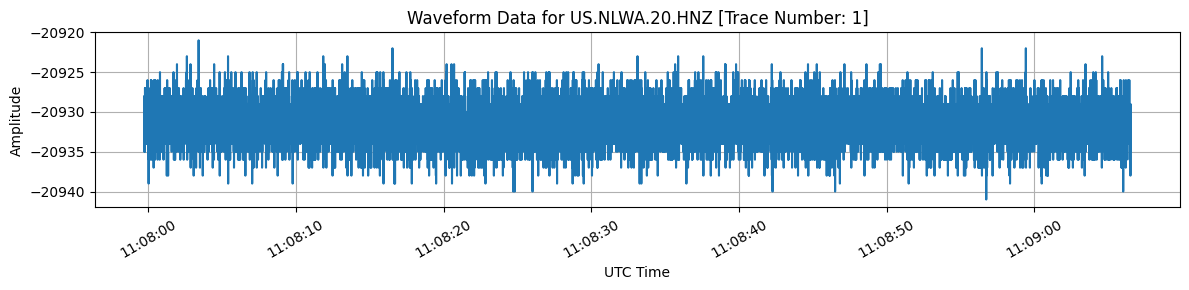

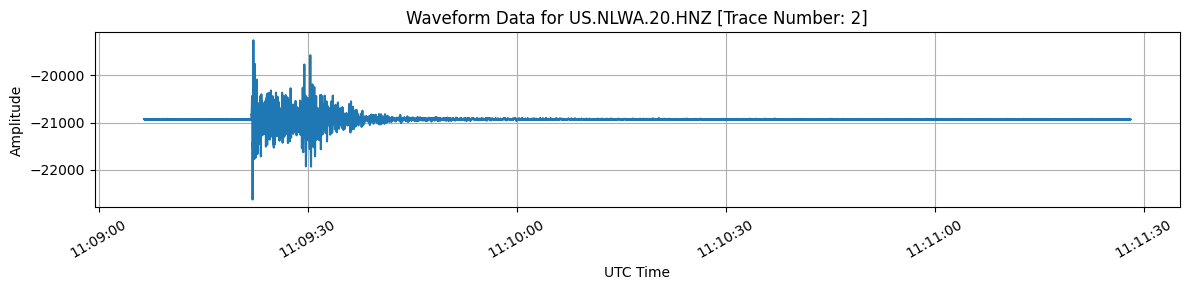

In [42]:
row_number = 0 # You can change this to any row number you want to retrieve

# Retrieve waveform data for a specific station and channel
st = client.get_waveforms(network=df.iloc[row_number].network, 
                            station=df.iloc[row_number].station, location="*", 
                            channel='HNZ', starttime=t1, endtime=t2)


print(f"Retrieved {len(st)} traces for station {df.iloc[row_number].station} ({df.iloc[row_number].network})")


import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tr_no = 0
for tr in st:
    tr_no += 1 # Count the trace number in the stream

    # Convert ObsPy UTCDateTime values to Python datetime objects
    # Convert each sample time to UTC datetime
    utc_times = [
        (tr.stats.starttime + i * tr.stats.delta).datetime
        for i in range(tr.stats.npts)
    ]
    
    plt.figure(figsize=(12, 3))
    plt.plot(utc_times, tr.data)
    plt.title(f"Waveform Data for {tr.id} [Trace Number: {tr_no}]")
    plt.xlabel("UTC Time")
    plt.ylabel("Amplitude")

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [34]:
gaps = st.get_gaps() # Check for gaps in the stream
print(gaps)

[]


In cases of multiple `Trace` objects inside a single `Stream` object, the traces can be combined using ObsPy's `merge()` method.

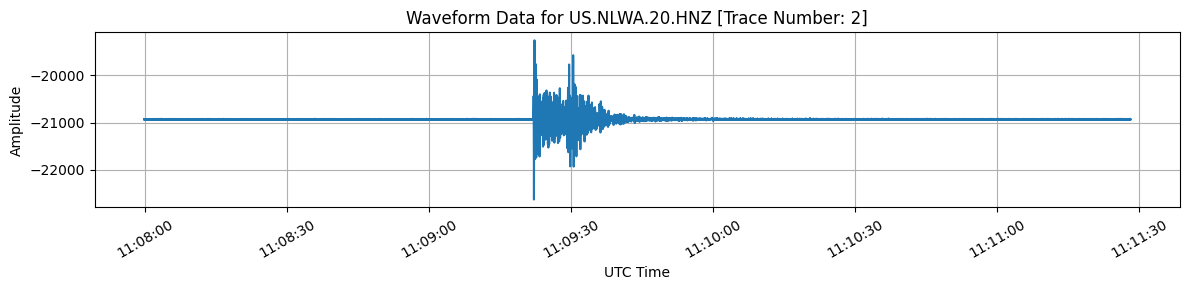

In [27]:
st.merge(method=1, fill_value="Interpolate") # Merge the traces in the stream, filling gaps by interpolation
tr = st[0] 
utc_times = [
    (tr.stats.starttime + i * tr.stats.delta).datetime
    for i in range(tr.stats.npts)
]
plt.figure(figsize=(12, 3))
plt.plot(utc_times, tr.data)
plt.title(f"Waveform Data for {tr.id} [Trace Number: {tr_no}]")
plt.xlabel("UTC Time")
plt.ylabel("Amplitude")

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=30)
plt.tight_layout()
plt.grid(True)
plt.show()

You just pulled real ground motion data from a station and plotted it. The ground motion data or seismogram records different waves that travel through the Earth at different speeds and therefore arrive at different times. The fastest wave arrives first (P-wave), followed by slower ones (Surface wave).

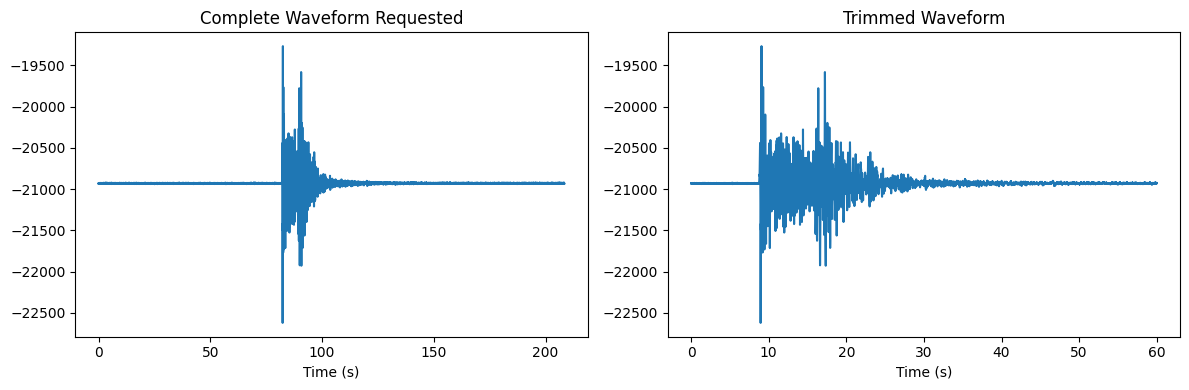

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(tr.times(),tr.data)
plt.xlabel("Time (s)")
plt.title("Complete Waveform Requested")

# Trim the waveform data to a specific time window
pick_time1 = 120
pick_time2 = 180

tr_trim = tr.copy()  # Create a copy of the trace to trim
tr_trim.trim(starttime=t1+pick_time1, endtime=t1+pick_time2)

plt.subplot(1,2,2)
plt.plot(tr_trim.times(),tr_trim.data)
plt.xlabel("Time (s)")
plt.title("Trimmed Waveform")

plt.tight_layout()

#### **Data Interpretation**

In the plot above, the y-axis is raw digital counts, not ground motion. The instrument doesn't record accelaration or velocity directly. Ground motion moves a mass, that motion is converted to a voltage, and a digitizer turns the voltage into integer counts. The counts are proportional to ground motion, but the proportionality constant (and its frequency dependence) lives in the **instrument response**.

Text(0.5, 1.0, 'Waveform After Instrument Response Removal')

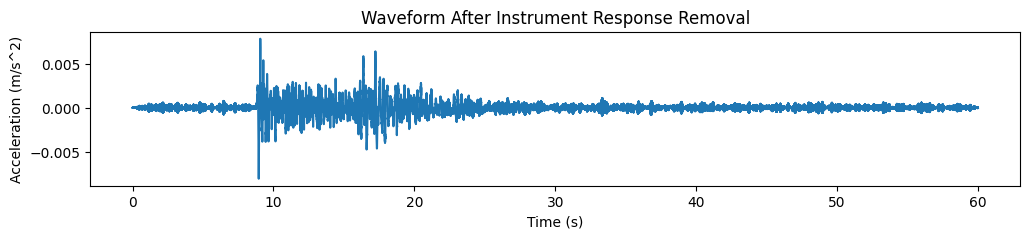

In [26]:

# To apply instrument response
tr_corrected = tr_trim.copy()
tr_corrected.remove_response(inventory=st_inv, output="ACC")  # Specify output units as velocity

plt.figure(figsize=(12, 2))
plt.plot(tr_corrected.times(), tr_corrected.data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Waveform After Instrument Response Removal")

Next, we compute a spectrogram. A spectrogram shows how signal energy is distributed across frequency and time. This helps us choose a filter band: we can keep the frequency range where the earthquake signal is strong and reduce frequencies dominated by noise.

Text(0.5, 1.0, 'Spectrogram of Trimmed Waveform')

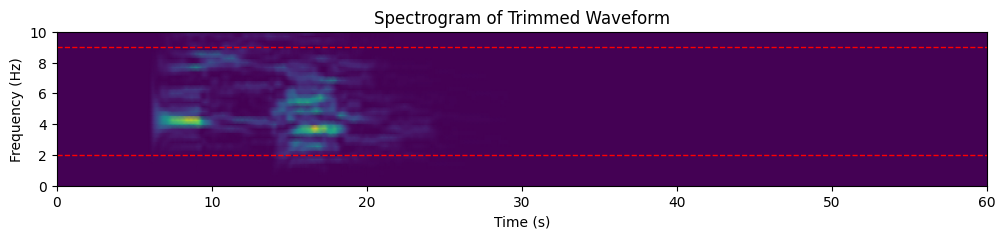

In [29]:
from scipy import signal
import numpy as np

# Sampling rate of the data
fs = tr_corrected.stats.sampling_rate

# Set window size and overlap for the spectrogram
nperseg = 700
noverlap = nperseg - 10

# Compute the spectrogram
f, t_spec, Sxx = signal.spectrogram(tr_corrected.data, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Adjust spectrogram time axis to match slice duration
t_spec = np.linspace(0, tr_corrected.times()[-1], Sxx.shape[1])

plt.figure(figsize=(12, 2))
plt.pcolormesh(t_spec, f, np.abs(Sxx), shading='gouraud')
plt.ylim(0, 10)
plt.axhline(y=2, color='red', linestyle='--', linewidth=1)
plt.axhline(y=9, color='red', linestyle='--', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Trimmed Waveform")

Below, we will do a bandpass filtering to remove frequency components outside the most prominent range.

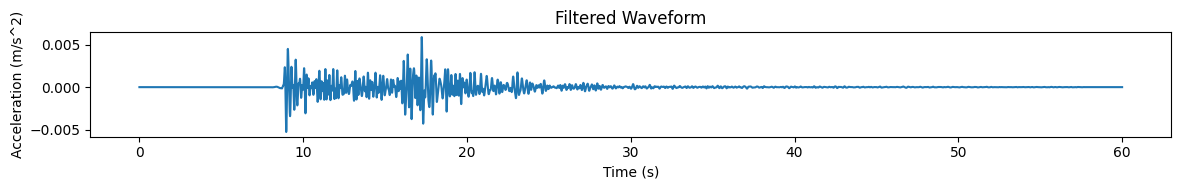

In [31]:
tr_filt = tr_corrected.copy()

# Bandpass between 1 and 10 Hz, 4-pole Butterworth, zero-phase
tr_filt.detrend("demean")      # remove DC offset
tr_filt.detrend("linear")      # remove linear trend
tr_filt.taper(max_percentage=0.05, type="hann")   # taper the ends to zero
tr_filt.filter("bandpass",
               freqmin=2.0,
               freqmax=9.0,
               corners=4,
               zerophase=True)

plt.figure(figsize=(12, 2))
plt.plot(tr_filt.times(), tr_filt.data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Filtered Waveform")
plt.tight_layout()